In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import ticker as mticker
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from math import ceil
import tol_colors as tc

In [ ]:
# ------------------ Inputs ------------------
cattle_multiClock_df = pd.read_csv('../analysis/b313/beast_bird_cattle_separate/cattle/PA-HA-NA-MP-multiClock/PA-HA-NA-MP_no_overlap.RC.cattle_human.log', sep='\t', comment='#')
cattle_singleClock_df = pd.read_csv('../analysis/b313/beast_bird_cattle_separate/cattle/PA-HA-NA-MP/PA-HA-NA-MP.cattle_human.relaxed.RC.log', sep='\t', comment='#')
avian_multiClock_df  = pd.read_csv('../analysis/b313/beast_bird_cattle_separate/avian/PA-HA-NA-MP-multiClock/bird_skunk.seed1.PA-HA-NA-MP_no_overlap.RC.bird_skunk.log', sep='\t', comment='#')
avian_singleClock_df = pd.read_csv('../analysis/b313/beast_bird_cattle_separate/avian/PA-HA-NA-MP/combined/combined.log', sep='\t', comment='#')

segment_lengths = {
    'PA': 2151,
    'HA': 1704,
    'NA': 1410,
    'MP': 936,} # 982 normally, 936 here because of removing overlap


def add_columns_segment(df: pd.DataFrame, segment: str, segment_length: int):
    df[f'{segment}.CP1+CP2.mu'] = (df[f'{segment}.CP1.mu'] + df[f'{segment}.CP2.mu'])
    df[f'{segment}.CP1_prop'] = df[f'{segment}.CP1.mu'] / (df[f'{segment}.CP1+CP2.mu'] + df[f'{segment}.CP3.mu'])
    df[f'{segment}.CP2_prop'] = df[f'{segment}.CP2.mu'] / (df[f'{segment}.CP1+CP2.mu'] + df[f'{segment}.CP3.mu'])
    df[f'{segment}.CP3_prop'] = df[f'{segment}.CP3.mu'] / (df[f'{segment}.CP1+CP2.mu'] + df[f'{segment}.CP3.mu'])
    df[f'{segment}.CP1+CP2_prop'] = df[f'{segment}.CP1_prop'] + df[f'{segment}.CP2_prop']

    df[f'{segment}.CP1+CP2_to_CP3_ratio'] = df[f'{segment}.CP1+CP2.mu'] / df[f'{segment}.CP3.mu']

    df[f'{segment}.CP1_rate'] = df[f'{segment}.CP1.mu'] * df[f'{segment}.meanRate']
    df[f'{segment}.CP2_rate'] = df[f'{segment}.CP2.mu'] * df[f'{segment}.meanRate']
    df[f'{segment}.CP3_rate'] = df[f'{segment}.CP3.mu'] * df[f'{segment}.meanRate']
    df[f'{segment}.CP1+CP2_rate'] = df[f'{segment}.CP1+CP2.mu'] * df[f'{segment}.meanRate']

    df[f'{segment}.dNdS'] = (df[f'{segment}.total_N'] / df[f'{segment}.utotal_N']) / (df[f'{segment}.total_S'] / df[f'{segment}.utotal_S'])
    df[f'{segment}.RC_clock_rate_est'] = (df[f'{segment}.total_S'] + df[f'{segment}.total_N']) / df['treeLength'] / segment_length
    
    
def add_columns_whole(df: pd.DataFrame, segment_length: int = 6201):
    df['CP1+CP2.mu'] = (df['CP1.mu'] + df['CP2.mu'])
    df['CP1_prop'] = df['CP1.mu'] / (df['CP1+CP2.mu'] + df['CP3.mu'])
    df['CP2_prop'] = df['CP2.mu'] / (df['CP1+CP2.mu'] + df['CP3.mu'])
    df['CP3_prop'] = df['CP3.mu'] / (df['CP1+CP2.mu'] + df['CP3.mu'])
    df['CP1+CP2_prop'] = df['CP1_prop'] + df['CP2_prop']

    df['CP1+CP2_to_CP3_ratio'] = df['CP1+CP2.mu'] / df['CP3.mu']

    df['CP1_rate'] = df['CP1.mu'] * df['default.meanRate']
    df['CP2_rate'] = df['CP2.mu'] * df['default.meanRate']
    df['CP3_rate'] = df['CP3.mu'] * df['default.meanRate']
    df['CP1+CP2_rate'] = df['CP1+CP2.mu'] * df['default.meanRate']

    df['dNdS'] = (df['total_N'] / df['utotal_N']) / (df['total_S'] / df['utotal_S'])
    df['RC_clock_rate_est'] = (df['total_S'] + df['total_N']) / df['treeLength'] / segment_length


for seg in ['PA', 'HA', 'NA', 'MP']:
    add_columns_segment(cattle_multiClock_df, seg, segment_lengths[seg])
    add_columns_segment(avian_multiClock_df, seg, segment_lengths[seg])

add_columns_whole(cattle_singleClock_df)
add_columns_whole(avian_singleClock_df)


/var/folders/ls/3swb_7515hv8jb0mjxshss480000gp/T/ipykernel_21553/2171047413.py:291: DeprecationWarning: tol_cset is soft-deprecated since 2.0, please use tol_colors.colorsets instead
  cset = tc.tol_cset('muted')


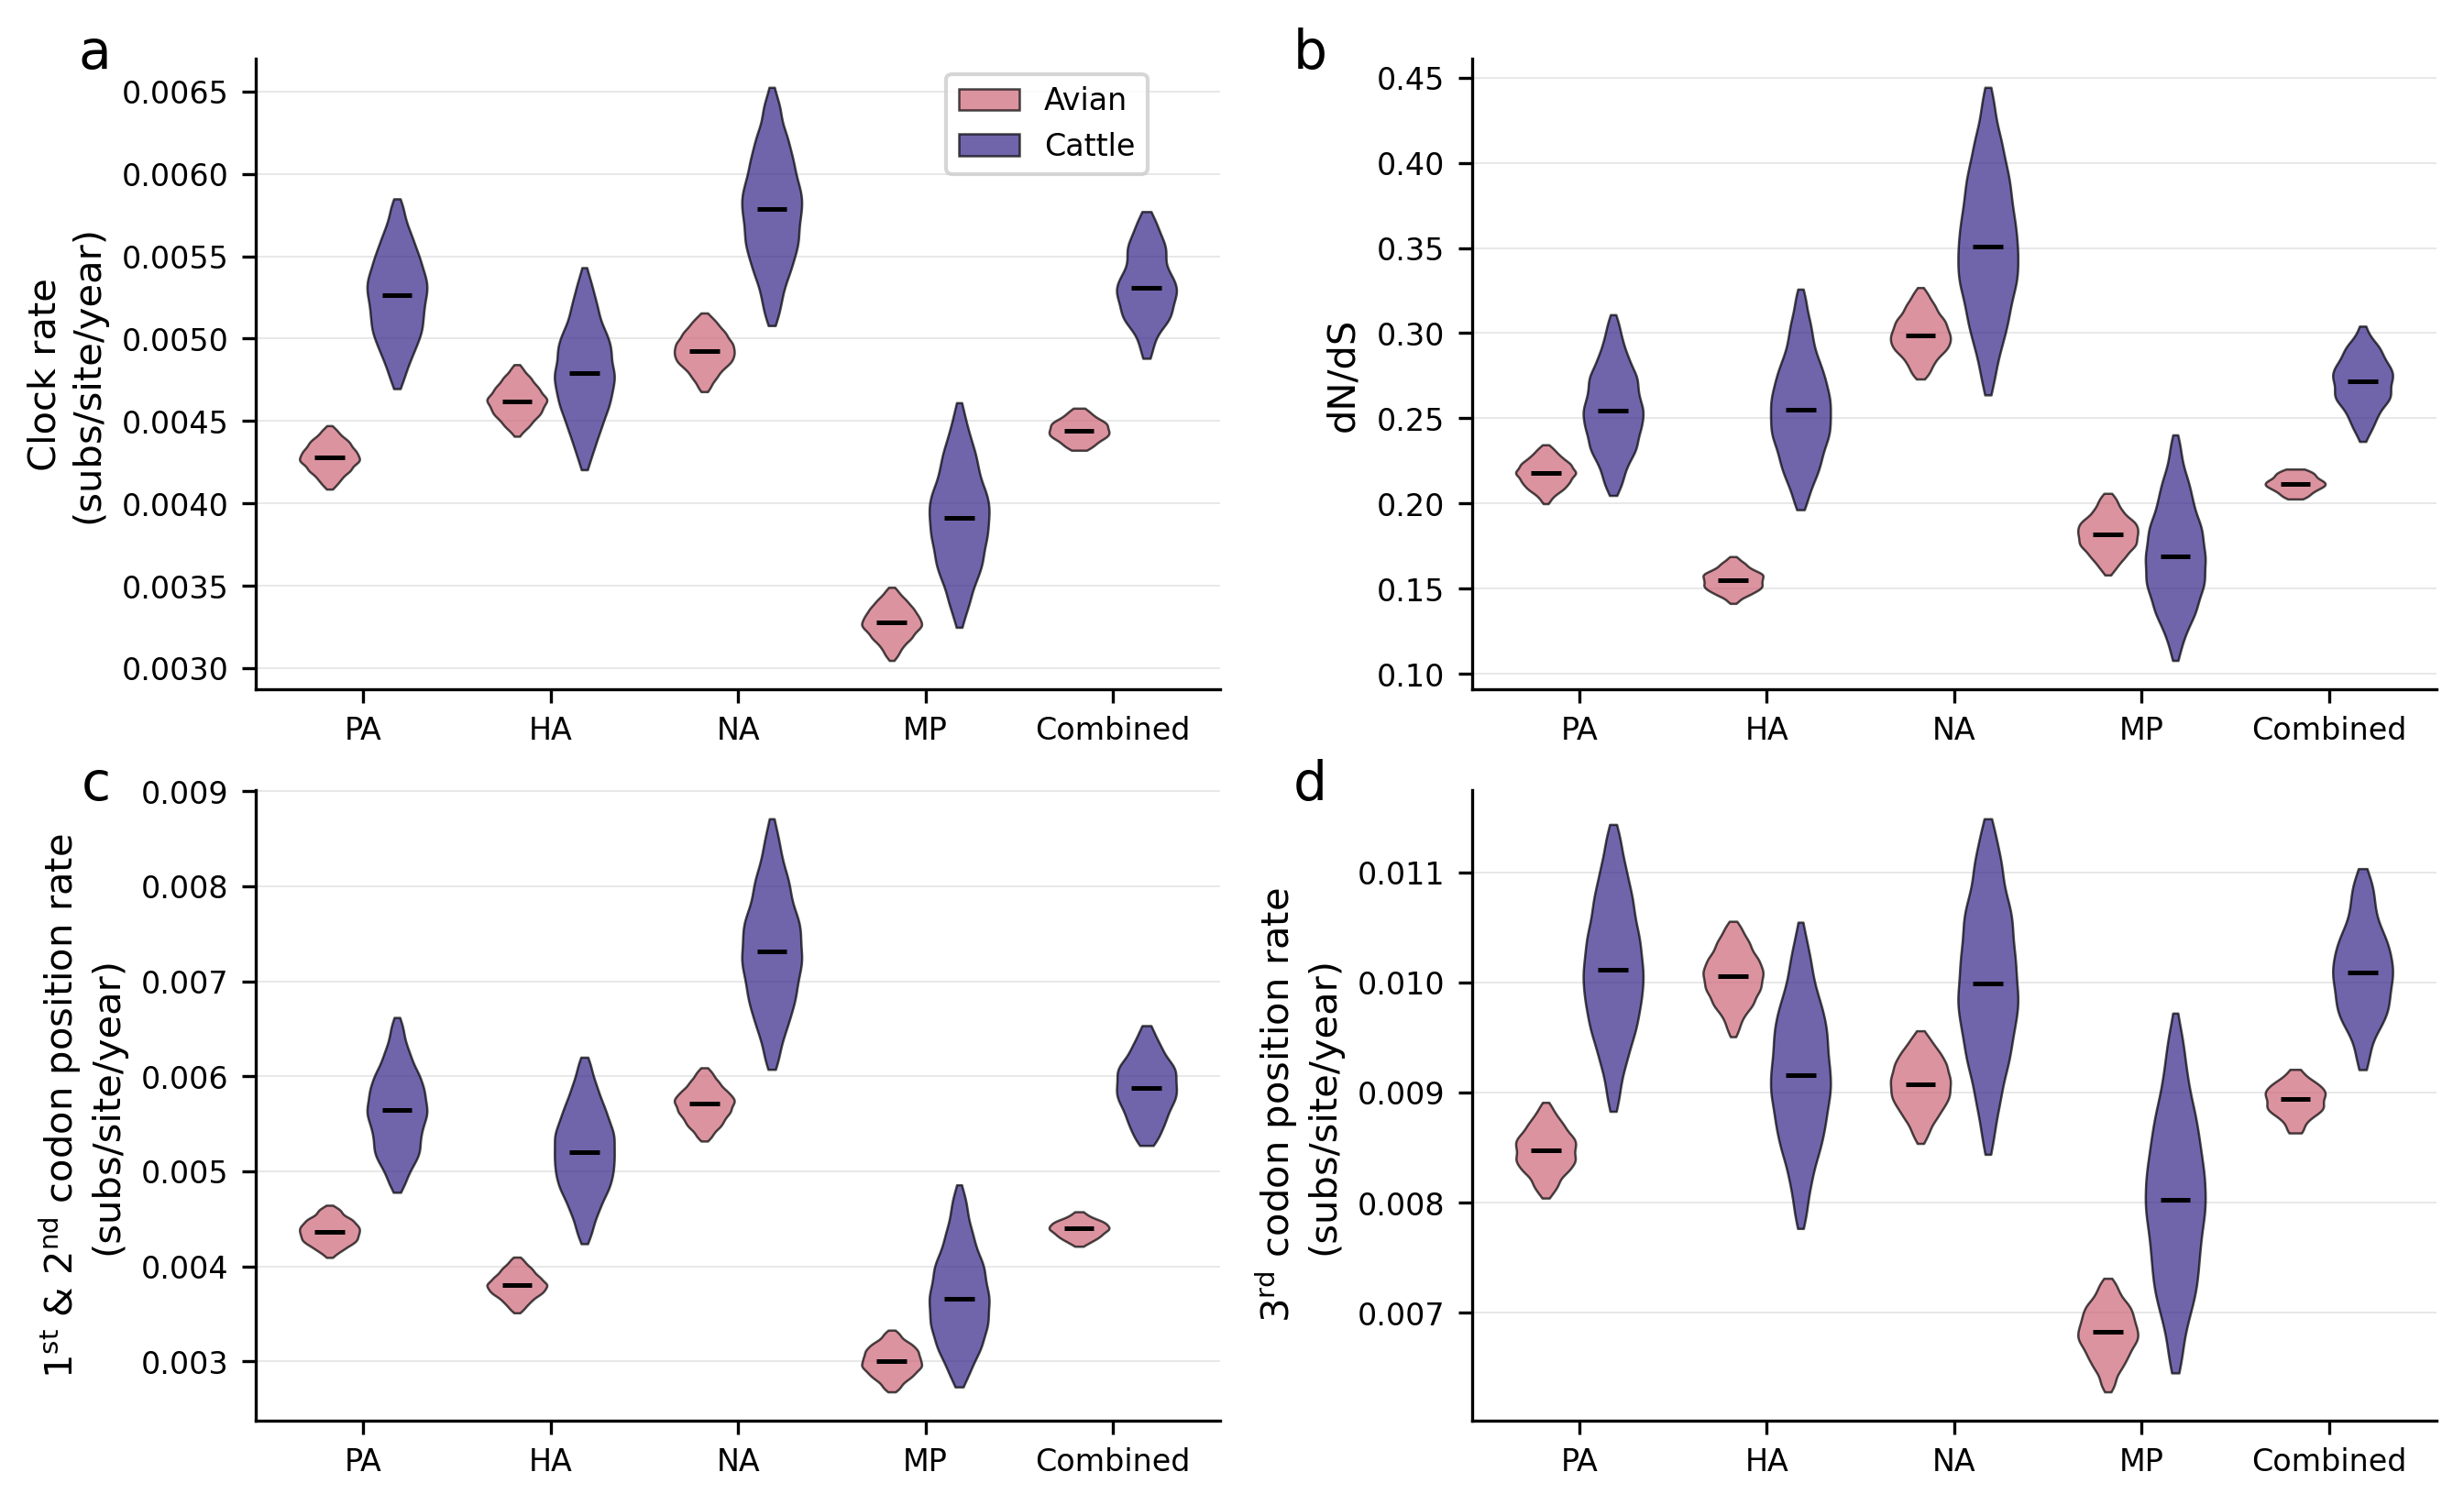

In [ ]:
# --- 95% HPD helper ---
def _hpd_interval(samples: np.ndarray, mass: float = 0.95) -> tuple[float, float]:
    x = np.asarray(samples, dtype=float)
    x = x[np.isfinite(x)]
    n = x.size
    if n == 0:
        return (np.nan, np.nan)
    if n == 1:
        return (x[0], x[0])
    x.sort()
    k = int(np.floor(mass * n))
    if k < 1:
        return (x.min(), x.max())
    spans = x[k:] - x[:n - k]
    i = np.argmin(spans)
    return (x[i], x[i + k])

# --- Single-panel drawer (now accepts ax) ---
def plot_clock_violins(
    bird_multi_df: pd.DataFrame,
    bird_single_df: pd.DataFrame,
    cattle_multi_df: pd.DataFrame,
    cattle_single_df: pd.DataFrame,
    multiClock_columns: list[str],
    singleClock_columns: list[str],
    burnin_frac: float = 0.1,
    figsize=(7.2, 3.8),
    fontsize: int = 11,
    labelsize: int = 12,
    titlesize: int = 12,
    ylabel: str = "Clock rate (subs/site/year)",
    outfile_prefix: str | None = None,
    *,
    ax: plt.Axes | None = None,     
    title: str | None = None,       
    add_legend: bool = True,        
    host_colors: dict | None = None 
):
    """
    Draw one panel of HPD-trimmed violins comparing Bird vs Cattle for the given columns.
    Returns (fig, ax). If ax is provided, fig will be the parent figure and not None.
    """
    # --- Style constants ---
    bird_color   = '#3A6EA5'
    cattle_color = '#D17A00'
    if host_colors:
        bird_color   = host_colors.get("Bird", bird_color)
        cattle_color = host_colors.get("Cattle", cattle_color)

    alpha = 0.7
    edge_color = 'black'
    linewidth = 0.6
    violin_width = 0.32
    offset = 0.18

    # --- Helpers ---
    def drop_burnin(df, frac=0.1):
        if frac <= 0 or frac >= 1:
            return df
        n = len(df)
        start = int(np.floor(n * frac))
        return df.iloc[start:].reset_index(drop=True)

    def collect_rates(df_multi, df_single, species_label):
        rows = []
        df_multi_b = drop_burnin(df_multi, burnin_frac)
        for seg_col in multiClock_columns:
            seg = seg_col.split('.')[0]
            vals = pd.to_numeric(df_multi_b[seg_col], errors='coerce').to_numpy(dtype=float)
            vals = vals[np.isfinite(vals)]
            if vals.size:
                lo, hi = _hpd_interval(vals, 0.95)
                vals = vals[(vals >= lo) & (vals <= hi)]
            rows.append({'segment': seg, 'species': species_label, 'values': vals})

        df_single_b = drop_burnin(df_single, burnin_frac)
        for single_col in singleClock_columns:
            seg = 'Combined'
            vals = pd.to_numeric(df_single_b[single_col], errors='coerce').to_numpy(dtype=float)
            vals = vals[np.isfinite(vals)]
            if vals.size:
                lo, hi = _hpd_interval(vals, 0.95)
                vals = vals[(vals >= lo) & (vals <= hi)]
            rows.append({'segment': seg, 'species': species_label, 'values': vals})
        return rows

    # --- Collect and organize data ---
    data = []
    data += collect_rates(bird_multi_df, bird_single_df, 'Bird')
    data += collect_rates(cattle_multi_df, cattle_single_df, 'Cattle')

    segments = [c.split('.')[0] for c in multiClock_columns] + ['Combined']
    positions = np.arange(len(segments))
    bird_positions   = positions - offset
    cattle_positions = positions + offset

    def get_vals(segment, species):
        for row in data:
            if row['segment'] == segment and row['species'] == species:
                return row['values']
        raise KeyError(f"No data for segment={segment}, species={species}")

    # --- Fonts before plotting ---
    plt.rcParams.update({
        'pdf.fonttype': 42,
        'ps.fonttype': 42,
        'font.size': fontsize,
        'axes.labelsize': labelsize,
        'axes.titlesize': titlesize,
    })

    # --- Figure / Axes ---
    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize, dpi=300)
        created_fig = True
    else:
        fig = ax.figure

    # --- Drawer ---
    def draw_violin(ax, values, pos, facecolor):
        if values.size == 0:
            return
        v = ax.violinplot(dataset=values, positions=[pos], widths=violin_width,
                          showmeans=False, showmedians=True, showextrema=False)
        for b in v['bodies']:
            b.set_facecolor(facecolor)
            b.set_edgecolor(edge_color)
            b.set_alpha(alpha)
            b.set_linewidth(linewidth)
        v['cmedians'].set_color(edge_color)
        v['cmedians'].set_linewidth(1.2)

    for i, seg in enumerate(segments):
        draw_violin(ax, get_vals(seg, 'Bird'),   bird_positions[i],   bird_color)
        draw_violin(ax, get_vals(seg, 'Cattle'), cattle_positions[i], cattle_color)

    ax.set_xticks(positions)
    ax.set_xticklabels(segments)
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title, pad=6)

    ax.yaxis.grid(True, linestyle='-', linewidth=0.4, alpha=0.35)
    ax.set_axisbelow(True)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    if add_legend:
        legend_handles = [
            Patch(facecolor=bird_color, edgecolor=edge_color, label='Avian', alpha=alpha, linewidth=linewidth),
            Patch(facecolor=cattle_color, edgecolor=edge_color, label='Cattle', alpha=alpha, linewidth=linewidth)
        ]
        ax.legend(handles=legend_handles, frameon=True, loc='upper left', bbox_to_anchor=(0.7, 1))

    if created_fig:
        fig.tight_layout()
        if outfile_prefix:
            fig.savefig(f'{outfile_prefix}.png', dpi=600)
            fig.savefig(f'{outfile_prefix}.pdf')
        # leave plt.show() to caller
    return fig, ax

# --- Multi-panel wrapper ---
def plot_clock_violins_panels(
    panels: list[dict],
    ncols: int = 2,
    figsize_per=(7.2, 3.8),
    sharey: bool = True,
    sharex: bool = True,
    suptitle: str | None = None,
    outfile_prefix: str | None = None,
    host_colors: dict | None = None,
    legend_on: str = "first"  # "first", "last", or "none"
):
    """
    Build a multi-panel figure.

    panels: list of dicts, each with the arguments for plot_clock_violins, e.g.:
      dict(
        bird_multi_df=..., bird_single_df=..., cattle_multi_df=..., cattle_single_df=...,
        multiClock_columns=[...], singleClock_columns=[...],
        ylabel="Clock rate ...", title="Panel A"
      )
    """
    n = len(panels)
    nrows = ceil(n / ncols)
    fig_w = figsize_per[0] * ncols
    fig_h = figsize_per[1] * nrows
    fig, axes = plt.subplots(nrows, ncols, figsize=(fig_w, fig_h), dpi=300,
                             sharex=sharex, sharey=sharey)
    if isinstance(axes, np.ndarray):
        axes = axes.ravel()
    else:
        axes = np.array([axes])

    # draw each panel
    for i, panel in enumerate(panels):
        ax = axes[i]
        # ensure only one legend if requested
        add_legend = (legend_on == "first" and i == 0) or (legend_on == "last" and i == n - 1) or (legend_on == "all" and True)
        # pass through common colors if provided
        if host_colors is not None:
            panel = {**panel, "host_colors": host_colors}
        plot_clock_violins(ax=ax, add_legend=add_legend, **panel)
        
    # fontsize for x and y ticks
    for ax in axes[:n]:
        ax.tick_params(axis='both', which='major', labelsize=fontsize)
    # fontsize for xlabel and ylabel
    for ax in axes[:n]:
        ax.xaxis.label.set_size(fontsize+2)
        ax.yaxis.label.set_size(fontsize+2)

    # remove any extra axes if panels < grid
    for j in range(n, len(axes)):
        fig.delaxes(axes[j])

    if suptitle:
        fig.suptitle(suptitle, y=0.995)

    fig.tight_layout(rect=(0, 0, 1, 0.98) if suptitle else None)

    if outfile_prefix:
        fig.savefig(f"{outfile_prefix}.png", dpi=600)
        fig.savefig(f"{outfile_prefix}.pdf")

    return fig, axes

fontsize = 8
panels = [
    dict(
        bird_multi_df=avian_multiClock_df,
        bird_single_df=avian_singleClock_df,
        cattle_multi_df=cattle_multiClock_df,
        cattle_single_df=cattle_singleClock_df,
        multiClock_columns=['PA.meanRate','HA.meanRate','NA.meanRate','MP.meanRate'],
        singleClock_columns=['default.meanRate'],
        ylabel="Clock rate\n(subs/site/year)",
        burnin_frac=0.5,
        fontsize=fontsize,
        title=None
    ),
    
    dict(
        bird_multi_df=avian_multiClock_df,
        bird_single_df=avian_singleClock_df,
        cattle_multi_df=cattle_multiClock_df,
        cattle_single_df=cattle_singleClock_df,
        multiClock_columns=['PA.dNdS', 'HA.dNdS', 'NA.dNdS', 'MP.dNdS'],
        singleClock_columns=['dNdS'],
        ylabel="dN/dS",
        burnin_frac=0.5,
        fontsize=fontsize,
        title=None
    ),
    
    dict(
        bird_multi_df=avian_multiClock_df,
        bird_single_df=avian_singleClock_df,
        cattle_multi_df=cattle_multiClock_df,
        cattle_single_df=cattle_singleClock_df,
        multiClock_columns=['PA.CP1+CP2_rate', 'HA.CP1+CP2_rate', 'NA.CP1+CP2_rate', 'MP.CP1+CP2_rate'],
        singleClock_columns=['CP1+CP2_rate'],
        ylabel = "1$^{\\mathrm{st}}$ & 2$^{\\mathrm{nd}}$ codon position rate\n(subs/site/year)",
        burnin_frac=0.5,
        fontsize=fontsize,
        title=None
    ),
    
    dict(
        bird_multi_df=avian_multiClock_df,
        bird_single_df=avian_singleClock_df,
        cattle_multi_df=cattle_multiClock_df,
        cattle_single_df=cattle_singleClock_df,
        multiClock_columns=['PA.CP3_rate', 'HA.CP3_rate', 'NA.CP3_rate', 'MP.CP3_rate'],
        singleClock_columns=['CP3_rate'],
        ylabel = "3$^{\\mathrm{rd}}$ codon position rate\n(subs/site/year)",
        burnin_frac=0.5,
        fontsize=fontsize,
        title=None
    ),
]

cset = tc.tol_cset('muted')
col_cattle = cset[1]      # cattle
col_avian = cset[0]  # avian 

fig, axes = plot_clock_violins_panels(
    panels, ncols=2, sharey=False, sharex=False,
    outfile_prefix="clock_violin_multi",
    host_colors={"Bird":col_avian,"Cattle":col_cattle},
    legend_on="first", figsize_per=(4.5,2.7)
)

labels = ['a', 'b', 'c', 'd']
for ax, label in zip(axes, labels):
    ax.text(-0.15, 1.05, label, transform=ax.transAxes,
            fontsize=fontsize+6, fontweight='normal', va='top', ha='right')
plt.show()

# create table with median and 95% HPD for each segment/species/clock, to be used in the supplement
# --- Table generation function ---
def create_summary_table(
    bird_multi_df: pd.DataFrame,
    bird_single_df: pd.DataFrame,
    cattle_multi_df: pd.DataFrame,
    cattle_single_df: pd.DataFrame,
    analyses: list[dict],
    burnin_frac: float = 0.5
) -> pd.DataFrame:
    """
    Generate a summary table with median and 95% HPD for all analyses.
    
    analyses: list of dicts with keys 'multiClock_columns', 'singleClock_columns', 'parameter_name'
    """
    
    def drop_burnin(df, frac=0.1):
        if frac <= 0 or frac >= 1:
            return df
        n = len(df)
        start = int(np.floor(n * frac))
        return df.iloc[start:].reset_index(drop=True)
    
    def compute_stats(values):
        """Compute median and 95% HPD"""
        if values.size == 0:
            return np.nan, np.nan, np.nan
        median = np.median(values)
        lo, hi = _hpd_interval(values, 0.95)
        return median, lo, hi
    
    results = []
    
    for analysis in analyses:
        multi_cols = analysis['multiClock_columns']
        single_cols = analysis['singleClock_columns']
        param_name = analysis['parameter_name']
        
        # Process multi-clock columns (separate segments)
        for species_name, multi_df, single_df in [
            ('Avian', bird_multi_df, bird_single_df),
            ('Cattle', cattle_multi_df, cattle_single_df)
        ]:
            # Multi-clock segments
            multi_df_b = drop_burnin(multi_df, burnin_frac)
            for seg_col in multi_cols:
                segment = seg_col.split('.')[0]
                vals = pd.to_numeric(multi_df_b[seg_col], errors='coerce').to_numpy(dtype=float)
                vals = vals[np.isfinite(vals)]
                
                if vals.size:
                    # Apply HPD trimming like in the plot
                    lo_trim, hi_trim = _hpd_interval(vals, 0.95)
                    vals = vals[(vals >= lo_trim) & (vals <= hi_trim)]
                    
                    median, hpd_lo, hpd_hi = compute_stats(vals)
                    
                    results.append({
                        'Parameter': param_name,
                        'Species': species_name,
                        'Segment': segment,
                        'Median': median,
                        'HPD_Lower': hpd_lo,
                        'HPD_Upper': hpd_hi,
                        'N': len(vals)
                    })
            
            # Single-clock (Combined)
            single_df_b = drop_burnin(single_df, burnin_frac)
            for single_col in single_cols:
                vals = pd.to_numeric(single_df_b[single_col], errors='coerce').to_numpy(dtype=float)
                vals = vals[np.isfinite(vals)]
                
                if vals.size:
                    # Apply HPD trimming
                    lo_trim, hi_trim = _hpd_interval(vals, 0.95)
                    vals = vals[(vals >= lo_trim) & (vals <= hi_trim)]
                    
                    median, hpd_lo, hpd_hi = compute_stats(vals)
                    
                    results.append({
                        'Parameter': param_name,
                        'Species': species_name,
                        'Segment': 'Combined',
                        'Median': median,
                        'HPD_Lower': hpd_lo,
                        'HPD_Upper': hpd_hi,
                        'N': len(vals)
                    })
    
    df = pd.DataFrame(results)
    return df


analyses = [
    {
        'parameter_name': 'Clock rate (subs/site/year)',
        'multiClock_columns': ['PA.meanRate', 'HA.meanRate', 'NA.meanRate', 'MP.meanRate'],
        'singleClock_columns': ['default.meanRate']
    },
    {
        'parameter_name': 'dN/dS',
        'multiClock_columns': ['PA.dNdS', 'HA.dNdS', 'NA.dNdS', 'MP.dNdS'],
        'singleClock_columns': ['dNdS']
    },
    {
        'parameter_name': 'CP1+CP2 rate (subs/site/year)',
        'multiClock_columns': ['PA.CP1+CP2_rate', 'HA.CP1+CP2_rate', 'NA.CP1+CP2_rate', 'MP.CP1+CP2_rate'],
        'singleClock_columns': ['CP1+CP2_rate']
    },
    {
        'parameter_name': 'CP3 rate (subs/site/year)',
        'multiClock_columns': ['PA.CP3_rate', 'HA.CP3_rate', 'NA.CP3_rate', 'MP.CP3_rate'],
        'singleClock_columns': ['CP3_rate']
    },
]

summary_df = create_summary_table(
    bird_multi_df=avian_multiClock_df,
    bird_single_df=avian_singleClock_df,
    cattle_multi_df=cattle_multiClock_df,
    cattle_single_df=cattle_singleClock_df,
    analyses=analyses,
    burnin_frac=0.5
)



In [ ]:
summary_df

# format table to combine median and hpd into one column, and round to 4 decimal places 
summary_df['Median (95% HPD)'] = summary_df.apply(
    lambda row: f"{row['Median']:.4f} ({row['HPD_Lower']:.4f} - {row['HPD_Upper']:.4f})",
    axis=1
)

final_df = summary_df[['Parameter', 'Species', 'Segment', 'Median (95% HPD)']]
final_df.to_csv("../tables/rate_comparison_summary_table.csv", index=False)

# convert final_df so that each row is a parameter/segment, and columns are "Avian" and "Cattle" with the median (95% HPD) values
pivot_df = final_df.pivot_table(index=['Parameter', 'Segment'], columns='Species', values='Median (95% HPD)', aggfunc='first').reset_index()
parameter_order = ['Clock rate (subs/site/year)', 'dN/dS', 'CP1+CP2 rate (subs/site/year)', 'CP3 rate (subs/site/year)']
segment_order = ['PA', 'HA', 'NA', 'MP', 'Combined']
pivot_df['Parameter'] = pd.Categorical(pivot_df['Parameter'], categories=parameter_order, ordered=True)
pivot_df['Segment'] = pd.Categorical(pivot_df['Segment'], categories=segment_order, ordered=True)
pivot_df = pivot_df.sort_values(['Parameter', 'Segment']).reset_index(drop=True)
pivot_df.columns = ['Parameter', 'Segment', 'Avian (Median [95% HPD])', 'Cattle (Median [95% HPD])']
pivot_df.to_csv("../tables/rate_comparison_summary_table_pivot.csv", index=False)
pivot_df

,Parameter,Segment,Avian (Median [95% HPD]),Cattle (Median [95% HPD])
0,Clock rate (subs/site/year),PA,0.0043 (0.0041 - 0.0044),0.0053 (0.0048 - 0.0057)
1,Clock rate (subs/site/year),HA,0.0046 (0.0044 - 0.0048),0.0048 (0.0043 - 0.0053)
2,Clock rate (subs/site/year),NA,0.0049 (0.0047 - 0.0051),0.0058 (0.0052 - 0.0064)
3,Clock rate (subs/site/year),MP,0.0033 (0.0031 - 0.0035),0.0039 (0.0034 - 0.0045)
4,Clock rate (subs/site/year),Combined,0.0044 (0.0043 - 0.0046),0.0053 (0.0050 - 0.0057)
5,dN/dS,PA,0.2178 (0.2030 - 0.2319),0.2544 (0.2077 - 0.2980)
6,dN/dS,HA,0.1548 (0.1432 - 0.1663),0.2551 (0.1990 - 0.3083)
7,dN/dS,NA,0.2988 (0.2750 - 0.3213),0.3506 (0.2759 - 0.4291)
8,dN/dS,MP,0.1819 (0.1613 - 0.2020),0.1689 (0.1163 - 0.2256)
9,dN/dS,Combined,0.2116 (0.2036 - 0.2199),0.2718 (0.2430 - 0.2982)


In [ ]:
wkw_colors = [
    "#B23A48",  
    "#2F8C8C",  
    "#C7852E",  
    "#1F5C3C",  
    "#1B2A49",  
]


def build_param_df_from_four_logs(
    *,
    bird_multi_df: pd.DataFrame,
    bird_single_df: pd.DataFrame,
    cattle_multi_df: pd.DataFrame,
    cattle_single_df: pd.DataFrame,
    param1_multi_cols: list[str],   
    param2_multi_cols: list[str],   
    param1_single_cols: list[str],  
    param2_single_cols: list[str],  
    burnin_frac: float = 0.10,
    analysis_label: str = "beast_bird_cattle_separate",
    segment_names: list[str] | None = None  
) -> pd.DataFrame:
    """
    Returns a long DataFrame with columns:
      ['analysis','unit','host','param1','param2']
    containing one row per posterior sample (after burn-in) for each (unit, host).
    """

    # --- sanity checks
    if len(param1_multi_cols) != len(param2_multi_cols):
        raise ValueError("param1_multi_cols and param2_multi_cols must have the same length.")
    if len(param1_single_cols) != len(param2_single_cols):
        raise ValueError("param1_single_cols and param2_single_cols must have the same length.")
    if len(param1_single_cols) != 1:
        pass

    if segment_names is None:
        segment_names = [c.split('.')[0] for c in param1_multi_cols]

    def _drop_burnin(df, frac):
        if not (0 < frac < 1): 
            return df
        start = int(np.floor(len(df) * frac))
        return df.iloc[start:].reset_index(drop=True)

    def _collect_host_block(df_multi, df_single, host_label: str) -> list[pd.DataFrame]:
        out_blocks = []

        dm = _drop_burnin(df_multi, burnin_frac)
        for seg, c1, c2 in zip(segment_names, param1_multi_cols, param2_multi_cols):
            if c1 not in dm.columns or c2 not in dm.columns:
                raise KeyError(f"Missing column(s) in multi df for segment '{seg}': {c1} or {c2}")
            block = pd.DataFrame({
                "analysis": analysis_label,
                "unit": seg,
                "host": host_label,
                "param1": pd.to_numeric(dm[c1], errors="coerce"),
                "param2": pd.to_numeric(dm[c2], errors="coerce"),
            })
            out_blocks.append(block)

        ds = _drop_burnin(df_single, burnin_frac)
        for c1, c2 in zip(param1_single_cols, param2_single_cols):
            if c1 not in ds.columns or c2 not in ds.columns:
                raise KeyError(f"Missing column(s) in single df: {c1} or {c2}")
            block = pd.DataFrame({
                "analysis": analysis_label,
                "unit": 'Combined',
                "host": host_label,
                "param1": pd.to_numeric(ds[c1], errors="coerce"),
                "param2": pd.to_numeric(ds[c2], errors="coerce"),
            })
            out_blocks.append(block)

        return out_blocks

    bird_blocks   = _collect_host_block(bird_multi_df,   bird_single_df,   "Bird")
    cattle_blocks = _collect_host_block(cattle_multi_df, cattle_single_df, "Cattle")

    df_long = pd.concat([*bird_blocks, *cattle_blocks], ignore_index=True)
    # drop rows where either param is NaN/inf
    df_long = df_long.replace([np.inf, -np.inf], np.nan).dropna(subset=["param1", "param2"])
    return df_long


param1_multi_cols  = ['PA.meanRate','HA.meanRate','NA.meanRate','MP.meanRate']      
param2_multi_cols  = ['PA.CP1+CP2_to_CP3_ratio','HA.CP1+CP2_to_CP3_ratio','NA.CP1+CP2_to_CP3_ratio','MP.CP1+CP2_to_CP3_ratio']  

param1_single_cols = ['default.meanRate']   
param2_single_cols = ['CP1+CP2_to_CP3_ratio']         

codon_sub_like_df = build_param_df_from_four_logs(
    bird_multi_df=avian_multiClock_df,
    bird_single_df=avian_singleClock_df,
    cattle_multi_df=cattle_multiClock_df,
    cattle_single_df=cattle_singleClock_df,
    param1_multi_cols=param1_multi_cols,
    param2_multi_cols=param2_multi_cols,
    param1_single_cols=param1_single_cols,
    param2_single_cols=param2_single_cols,
    burnin_frac=0.10,
    analysis_label="beast_bird_cattle_separate",  
    segment_names=['PA','HA','NA','MP']           
)

codon_sub_like_df

,analysis,unit,host,param1,param2
0,beast_bird_cattle_separate,PA,Bird,0.002102,0.510482
1,beast_bird_cattle_separate,PA,Bird,0.002109,0.511332
2,beast_bird_cattle_separate,PA,Bird,0.002196,0.503816
3,beast_bird_cattle_separate,PA,Bird,0.002126,0.503816
4,beast_bird_cattle_separate,PA,Bird,0.002126,0.510789
...,...,...,...,...,...
50173,beast_bird_cattle_separate,Combined,Cattle,0.005016,0.543361
50174,beast_bird_cattle_separate,Combined,Cattle,0.005424,0.581106
50175,beast_bird_cattle_separate,Combined,Cattle,0.005028,0.616606
50176,beast_bird_cattle_separate,Combined,Cattle,0.005171,0.607930


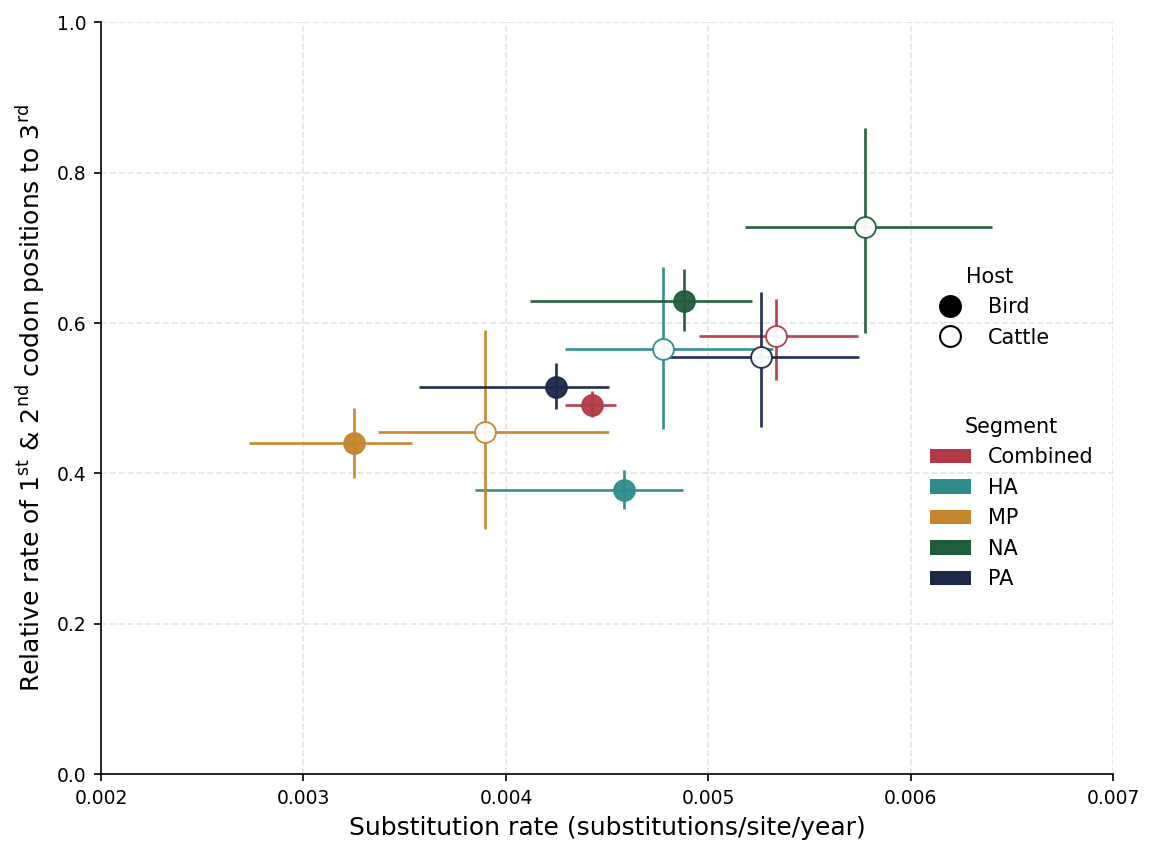

In [ ]:
def plot_param_against_param_for_each_unit_host(
    df: pd.DataFrame,
    *,
    param1: str = "dNdS",
    param2: str = "clock_rate",
    analysis: str = "beast_bird_cattle_separate",
    exclude_units_substr=("dnds",),
    hosts=None,
    units=None,
    logy=True,
    trim_hpd: float = 0.95,
    figsize=(9, 5),
    outfile_prefix=None,
    unit_color: dict | None = None,
    marker_shape: str = "o",
    xlabel=None,
    ylabel=None,
    elinewidth: float = 1.3,
    capsize: float = 0.0,
    scatter_size: float = 36,
    scatter_edgewidth: float = 0.9,
    fontsize_ticks: int = 10,
    fontsize_labels: int = 12,
    fontsize_title: int = 13,
    fontsize_legend: int = 10,
    xlim: tuple[float, float] | None = None,   # <-- new
    ylim: tuple[float, float] | None = None,   # <-- new
    cmap=None # list of colors or a colormap (e.g. plt.cm.viridis)
):
    """
    For each gene segment ('unit') and host, plot median(param1) vs median(param2)
    with 95% HPD bars for each dimension.
    """

    # --- Apply font configuration before plotting ---
    plt.rcParams.update({
        'pdf.fonttype': 42,
        'ps.fonttype': 42,
        'axes.labelsize': fontsize_labels,
        'axes.titlesize': fontsize_title,
        'xtick.labelsize': fontsize_ticks,
        'ytick.labelsize': fontsize_ticks,
        'legend.fontsize': fontsize_legend,
        'font.size': fontsize_labels  # base font size (affects titles etc.)
    })

    # --- 1) Filter ---
    d_main = df[df["analysis"] == analysis].copy()

    if units is None:
        units_main = sorted(
            u for u in d_main["unit"].dropna().unique()
            if not any(s.lower() in str(u).lower() for s in exclude_units_substr)
        )
    else:
        units_main = [u for u in units if u in d_main["unit"].unique()]

    d = d_main[["unit", "host", param1, param2]].dropna()

    if hosts is None:
        hosts_all = sorted(d["host"].dropna().unique())
    else:
        hosts_all = [h for h in hosts if h in d["host"].dropna().unique()]

    if d.empty or not units_main or not hosts_all:
        raise ValueError("No data left after filtering (check params/analysis/units/hosts).")
    
    def _normalize_unit_colors(units_main, unit_color, cmap):
        """
        Return a dict {unit: color} derived from (in priority order):
        1) unit_color (dict or list-like)
        2) cmap (list-like or mpl colormap)
        3) mpl default color cycle
        """
        # 1) If dict, fill any missing units from default cycle
        if isinstance(unit_color, dict):
            out = unit_color.copy()
            cycle = plt.rcParams["axes.prop_cycle"].by_key().get(
                "color",
                ["#1f77b4","#ff7f0e","#2ca02c","#d62728","#9467bd",
                "#8c564b","#e377c2","#7f7f7f","#bcbd22","#17becf"]
            )
            for i, u in enumerate(units_main):
                out.setdefault(u, cycle[i % len(cycle)])
            return out

        # 2) If list/tuple provided for unit_color, map in order
        if unit_color is not None:
            colors = list(unit_color)
            if len(colors) < len(units_main):
                raise ValueError("Not enough colors in unit_color for the number of units.")
            return {u: colors[i] for i, u in enumerate(units_main)}

        # 3) Use cmap if provided
        if cmap is not None:
            # matplotlib colormap object
            if hasattr(cmap, "N"):
                # sample evenly across the colormap
                idx = np.linspace(0, cmap.N - 1, num=len(units_main), dtype=int)
                colors = [cmap(i) for i in idx]
            else:
                colors = list(cmap)
            if len(colors) < len(units_main):
                raise ValueError("Not enough colors in cmap for the number of units.")
            return {u: colors[i] for i, u in enumerate(units_main)}

        # 4) Fallback to default cycle
        cycle = plt.rcParams["axes.prop_cycle"].by_key().get(
            "color",
            ["#1f77b4","#ff7f0e","#2ca02c","#d62728","#9467bd",
            "#8c564b","#e377c2","#7f7f7f","#bcbd22","#17becf"]
        )
        return {u: cycle[i % len(cycle)] for i, u in enumerate(units_main)}

    unit_color = _normalize_unit_colors(units_main, unit_color, cmap)


    # --- 3) Host style (filled vs hollow) ---
    host_filled = {h: (i % 2 == 0) for i, h in enumerate(hosts_all)}

    # --- 4) Figure ---
    fig = plt.figure(figsize=figsize, dpi=150)
    ax = plt.gca()

    # --- 5) Plot points ---
    any_point = False
    for u in units_main:
        for h in hosts_all:
            sub = d[(d["unit"] == u) & (d["host"] == h)]
            if sub.empty:
                continue

            x = sub[param1].to_numpy(dtype=float)
            y = sub[param2].to_numpy(dtype=float)
            x, y = x[np.isfinite(x)], y[np.isfinite(y)]
            if x.size == 0 or y.size == 0:
                continue

            if trim_hpd and x.size > 1:
                xl, xh = _hpd_interval(x, mass=trim_hpd)
                x = x[(x >= xl) & (x <= xh)]
            if trim_hpd and y.size > 1:
                yl, yh = _hpd_interval(y, mass=trim_hpd)
                y = y[(y >= yl) & (y <= yh)]

            x_med, y_med = np.median(x), np.median(y)
            x_low, x_high = (_hpd_interval(x, 0.95) if x.size > 1 else (x_med, x_med))
            y_low, y_high = (_hpd_interval(y, 0.95) if y.size > 1 else (y_med, y_med))

            xerr = np.array([[x_med - x_low], [x_high - x_med]])
            yerr = np.array([[y_med - y_low], [y_high - y_med]])

            filled = host_filled[h]
            face, edge = (unit_color[u] if filled else "white"), unit_color[u]

            ax.errorbar(
                x_med, y_med,
                xerr=xerr, yerr=yerr,
                fmt=marker_shape,
                ms=np.sqrt(scatter_size),
                mfc=face, mec=edge, mew=scatter_edgewidth,
                ecolor=unit_color[u], elinewidth=elinewidth,
                capsize=capsize, alpha=0.95
            )
            any_point = True

    if not any_point:
        raise ValueError("No (unit, host) combinations had finite data to plot.")

    # --- 6) Scales and labels ---
    if logy:
        ax.set_yscale("log")

        # ensure visible labels even if range avoids pure powers of 10
        major_locator = mticker.LogLocator(base=10.0, subs=(1.0, 2.0, 5.0))
        minor_locator = mticker.LogLocator(base=10.0, subs=np.arange(1, 10) * 0.1)
        ax.yaxis.set_major_locator(major_locator)
        ax.yaxis.set_minor_locator(minor_locator)
        ax.yaxis.set_major_formatter(mticker.LogFormatterSciNotation(base=10, labelOnlyBase=False))
        ax.yaxis.set_minor_formatter(mticker.NullFormatter())
        ax.tick_params(axis="y", which="major", labelsize=fontsize_ticks)
    else:
        ax.tick_params(axis="y", labelsize=fontsize_ticks)

    ax.tick_params(axis="x", labelsize=fontsize_ticks)
    ax.set_xlabel(xlabel or param1, fontsize=fontsize_labels)
    ax.set_ylabel(ylabel or param2, fontsize=fontsize_labels)

    # Optional axis limits
    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)

    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)

    ax.grid(True, which="both", linestyle="--", alpha=0.35)
    plt.tight_layout(pad=1.5)


    # --- 7) Legends ---
    # Unit color legend
    unit_handles = [Patch(facecolor=unit_color[u], edgecolor="none", label=str(u)) for u in units_main]
    leg1 = ax.legend(handles=unit_handles, title="Segment", frameon=False,
                     loc="upper left", bbox_to_anchor=(0.8, 0.5),
                     title_fontsize=fontsize_legend, fontsize=fontsize_legend)
    ax.add_artist(leg1)

    # Host fill style legend
    host_handles = []
    for h in hosts_all:
        filled = host_filled[h]
        host_handles.append(Line2D([0], [0],
            marker=marker_shape, linestyle="None",
            markerfacecolor=("black" if filled else "none"),
            markeredgecolor="black",
            markersize=np.sqrt(scatter_size),
            label=str(h)))
    ax.legend(handles=host_handles, title="Host", frameon=False,
              loc="upper left", bbox_to_anchor=(0.8, 0.7),
              title_fontsize=fontsize_legend, fontsize=fontsize_legend)

    # --- 8) Save ---
    if outfile_prefix:
        for ext in ("svg", "png"):
            fname = f"{outfile_prefix}.{ext}"
            plt.savefig(fname, dpi=300, bbox_inches="tight")
            print(f"Saved: {fname}")

    return ax


plot_param_against_param_for_each_unit_host(
    df=codon_sub_like_df,
    param1="param1",
    param2="param2",
    analysis="beast_bird_cattle_separate",
    figsize=(8,6),
    xlabel="Substitution rate (substitutions/site/year)",
    ylabel = r"Relative rate of 1$^{\mathrm{st}}$ & 2$^{\mathrm{nd}}$ codon positions to 3$^{\mathrm{rd}}$",
    scatter_size=100,
    logy=False,
    fontsize_ticks=9,
    fontsize_labels=12,
    fontsize_title=13,
    fontsize_legend=10,
    xlim=(2e-3, 7e-3),
    ylim=(0, 1),
    unit_color=wkw_colors,
)

plt.show()